In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

races = pd.read_csv("../data/raw/races.csv")
lap_times = pd.read_csv("../data/raw/lap_times.csv")
pit_stops = pd.read_csv("../data/raw/pit_stops.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
results = pd.read_csv("../data/raw/results.csv")

print("Races:", races.shape)
print("Lap Times:", lap_times.shape)
print("Pit Stops:", pit_stops.shape)
print("Drivers:", drivers.shape)
print("Results:", results.shape)

races.head()


Races: (1125, 18)
Lap Times: (589081, 6)
Pit Stops: (11371, 7)
Drivers: (861, 9)
Results: (26759, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [74]:
# Lap Times
lap_times.head()
lap_times.info()
lap_times.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589081 entries, 0 to 589080
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   raceId        589081 non-null  int64 
 1   driverId      589081 non-null  int64 
 2   lap           589081 non-null  int64 
 3   position      589081 non-null  int64 
 4   time          589081 non-null  object
 5   milliseconds  589081 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 27.0+ MB


,raceId,driverId,lap,position,milliseconds
count,589081.000000,589081.000000,589081.000000,589081.000000,5.890810e+05
mean,600.544465,325.796446,30.018104,9.661951,9.579945e+04
std,434.375976,387.561736,18.407126,5.528553,7.639973e+04
min,1.000000,1.000000,1.000000,1.000000,5.540400e+04
25%,140.000000,16.000000,14.000000,5.000000,8.204100e+04
50%,861.000000,48.000000,29.000000,9.000000,9.060800e+04
75%,1003.000000,822.000000,44.000000,14.000000,1.019300e+05
max,1144.000000,862.000000,87.000000,24.000000,7.507547e+06


In [75]:
# Pit Stops
pit_stops.head()
pit_stops.info()
pit_stops.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11371 entries, 0 to 11370
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        11371 non-null  int64 
 1   driverId      11371 non-null  int64 
 2   stop          11371 non-null  int64 
 3   lap           11371 non-null  int64 
 4   time          11371 non-null  object
 5   duration      11371 non-null  object
 6   milliseconds  11371 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 622.0+ KB


,raceId,driverId,stop,lap,milliseconds
count,11371.000000,11371.000000,11371.000000,11371.000000,1.137100e+04
mean,981.194882,549.734500,1.787969,25.387389,8.523050e+04
std,92.326831,383.734981,1.521462,14.831497,3.104273e+05
min,841.000000,1.000000,1.000000,1.000000,1.289700e+04
25%,895.000000,20.000000,1.000000,13.000000,2.193750e+04
50%,971.000000,817.000000,2.000000,25.000000,2.360600e+04
75%,1065.000000,835.000000,2.000000,36.000000,2.654400e+04
max,1144.000000,862.000000,70.000000,78.000000,3.069017e+06


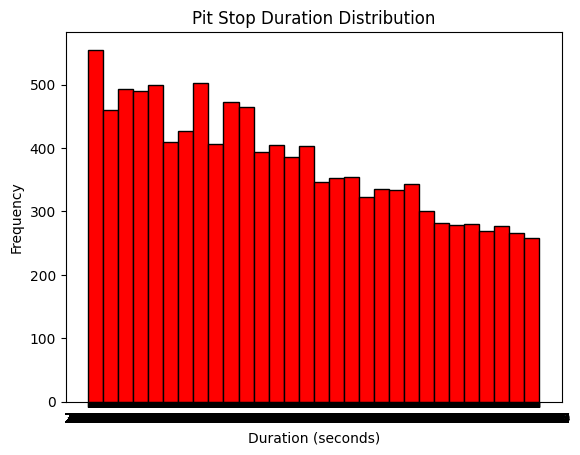

In [76]:
# Plot histogram of pit stop durations
import matplotlib.pyplot as plt

plt.hist(pit_stops['duration'], bins=30, edgecolor='black', color='red')
plt.title("Pit Stop Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

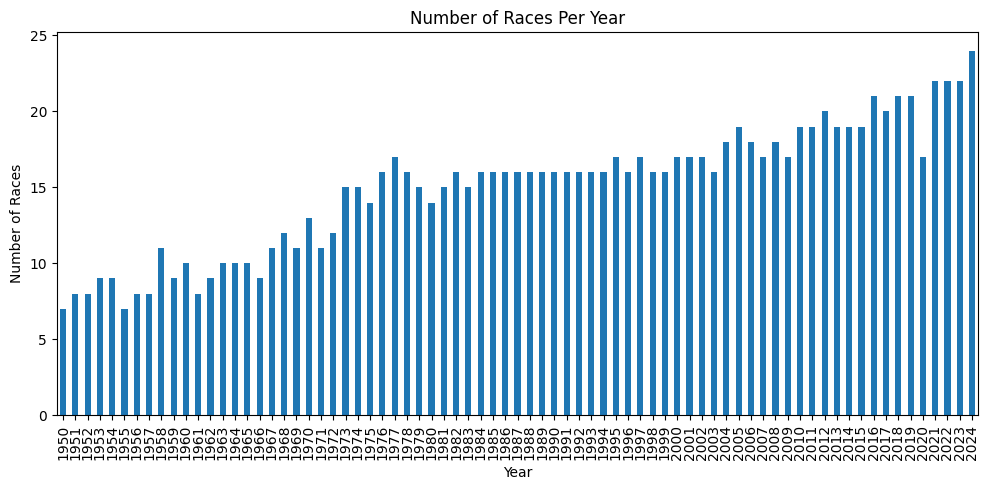

In [77]:
races_per_year = races['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
races_per_year.plot(kind='bar')
plt.title("Number of Races Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Races")
plt.tight_layout()
plt.show()

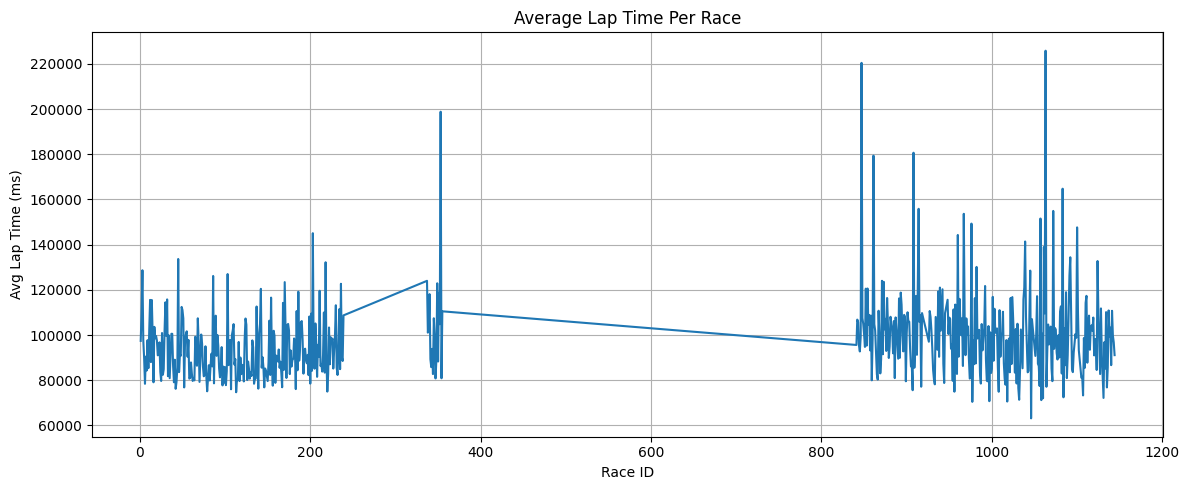

In [78]:
avg_lap_times = lap_times.groupby('raceId')['milliseconds'].mean()

plt.figure(figsize=(12, 5))
avg_lap_times.plot()
plt.title("Average Lap Time Per Race")
plt.xlabel("Race ID")
plt.ylabel("Avg Lap Time (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()

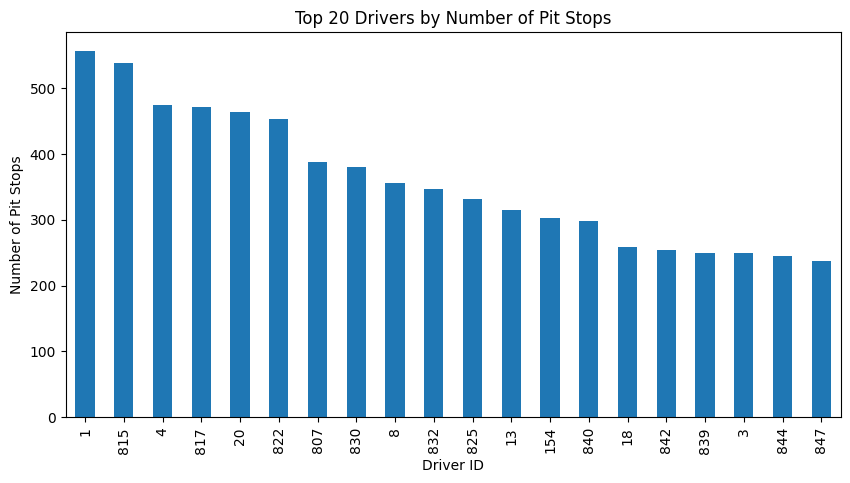

In [79]:
pit_count = pit_stops['driverId'].value_counts().head(20)

plt.figure(figsize=(10,5))
pit_count.plot(kind='bar')
plt.title("Top 20 Drivers by Number of Pit Stops")
plt.xlabel("Driver ID")
plt.ylabel("Number of Pit Stops")
plt.show()

In [80]:
lap_summary = lap_times.groupby(['raceId', 'driverId']).agg({
    'lap':'max',
    'milliseconds':['mean','sum','std']
}).reset_index()

lap_summary.columns = ['raceId', 'driverId', 'total_laps', 'avg_lap_time', 'total_race_time', 'lap_time_std']
lap_summary.head()

,raceId,driverId,total_laps,avg_lap_time,total_race_time,lap_time_std
0,1,1,58,97563.758621,5658698,16066.158258
1,1,2,58,97635.672414,5662869,14275.663645
2,1,3,58,97612.172414,5661506,16311.606142
3,1,4,58,97597.637931,5660663,16337.006698
4,1,6,17,91822.235294,1560978,3476.084499


In [81]:
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors = 'coerce')
pit_summary = pit_stops.groupby(['raceId', 'driverId']).agg({
    'stop': 'count',           # Number of pit stops
    'duration': 'sum'          # Total time spent in pits
}).reset_index()

pit_summary.columns = ['raceId', 'driverId', 'num_pit_stops', 'total_pit_time']

pit_summary.head()

,raceId,driverId,num_pit_stops,total_pit_time
0,841,1,2,46.426
1,841,2,2,48.092
2,841,3,1,23.716
3,841,4,3,72.165
4,841,5,1,24.865


In [82]:
merged_data = pd.merge(lap_summary, pit_summary, on=['raceId', 'driverId'], how='left')

merged_data['num_pit_stops'] = merged_data['num_pit_stops'].fillna(0)
merged_data['total_pit_time'] = merged_data['total_pit_time'].fillna(0)

merged_data.head()

,raceId,driverId,total_laps,avg_lap_time,total_race_time,lap_time_std,num_pit_stops,total_pit_time
0,1,1,58,97563.758621,5658698,16066.158258,0.0,0.0
1,1,2,58,97635.672414,5662869,14275.663645,0.0,0.0
2,1,3,58,97612.172414,5661506,16311.606142,0.0,0.0
3,1,4,58,97597.637931,5660663,16337.006698,0.0,0.0
4,1,6,17,91822.235294,1560978,3476.084499,0.0,0.0


In [83]:
drivers = pd.read_csv("../data/raw/drivers.csv")

drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']

merged_with_names = pd.merge(merged_data, drivers[['driverId', 'driver_name']], on='driverId', how='left')

merged_with_names.head()

,raceId,driverId,total_laps,avg_lap_time,total_race_time,lap_time_std,num_pit_stops,total_pit_time,driver_name
0,1,1,58,97563.758621,5658698,16066.158258,0.0,0.0,Lewis Hamilton
1,1,2,58,97635.672414,5662869,14275.663645,0.0,0.0,Nick Heidfeld
2,1,3,58,97612.172414,5661506,16311.606142,0.0,0.0,Nico Rosberg
3,1,4,58,97597.637931,5660663,16337.006698,0.0,0.0,Fernando Alonso
4,1,6,17,91822.235294,1560978,3476.084499,0.0,0.0,Kazuki Nakajima


In [84]:
results = pd.read_csv("../data/raw/results.csv")

results_trimmed = results[['raceId', 'driverId', 'positionOrder', 'grid', 'points', 'statusId']]

final_data = pd.merge(merged_with_names, results_trimmed, on=['raceId', 'driverId'], how='left')

final_data.head()

,raceId,driverId,total_laps,avg_lap_time,total_race_time,lap_time_std,num_pit_stops,total_pit_time,driver_name,positionOrder,grid,points,statusId
0,1,1,58,97563.758621,5658698,16066.158258,0.0,0.0,Lewis Hamilton,20,18,0.0,2
1,1,2,58,97635.672414,5662869,14275.663645,0.0,0.0,Nick Heidfeld,10,9,0.0,1
2,1,3,58,97612.172414,5661506,16311.606142,0.0,0.0,Nico Rosberg,6,5,3.0,1
3,1,4,58,97597.637931,5660663,16337.006698,0.0,0.0,Fernando Alonso,5,10,4.0,1
4,1,6,17,91822.235294,1560978,3476.084499,0.0,0.0,Kazuki Nakajima,18,11,0.0,3


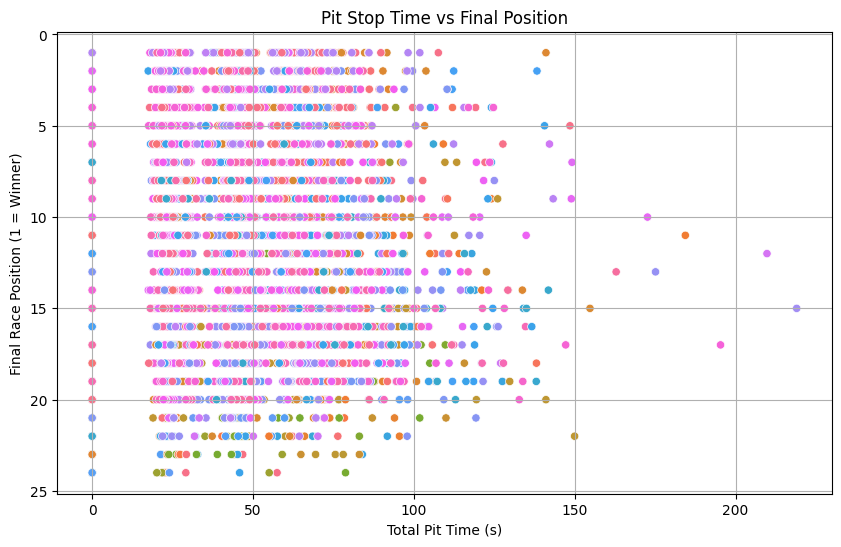

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=final_data, x='total_pit_time', y='positionOrder', hue='driver_name', legend=False)
plt.title("Pit Stop Time vs Final Position")
plt.xlabel("Total Pit Time (s)")
plt.ylabel("Final Race Position (1 = Winner)")
plt.gca().invert_yaxis()  # Because 1st place is better than 20th
plt.grid(True)
plt.show()

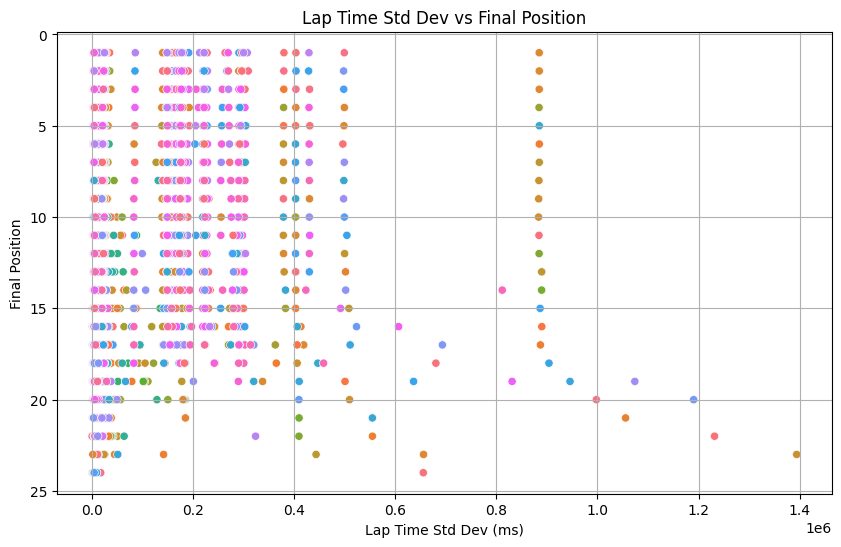

In [86]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=final_data, x='lap_time_std', y='positionOrder', hue='driver_name', legend=False)
plt.title("Lap Time Std Dev vs Final Position")
plt.xlabel("Lap Time Std Dev (ms)")
plt.ylabel("Final Position")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

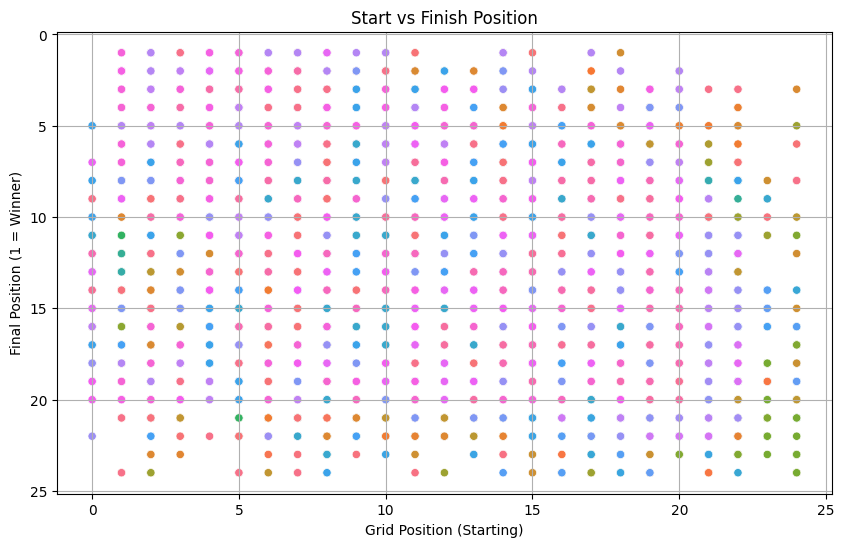

In [87]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_data, x='grid', y='positionOrder', hue='driver_name', legend=False)
plt.title("Start vs Finish Position")
plt.xlabel("Grid Position (Starting)")
plt.ylabel("Final Position (1 = Winner)")
plt.gca().invert_yaxis()  # So 1st place is at the top
plt.grid(True)
plt.show()

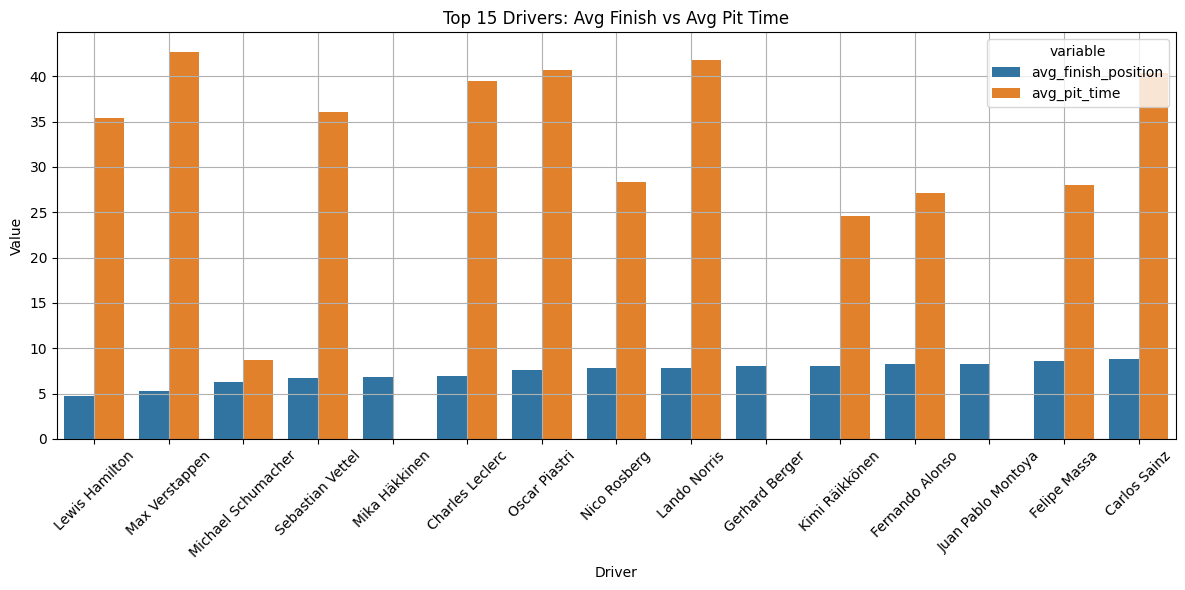

In [88]:
driver_summary_reset = driver_summary.reset_index().sort_values('avg_finish_position').head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=driver_summary_reset.melt(id_vars='driver_name'), x='driver_name', y='value', hue='variable')
plt.title("Top 15 Drivers: Avg Finish vs Avg Pit Time")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.xlabel("Driver")
plt.grid(True)
plt.tight_layout()
plt.show()


In [89]:
features = ['avg_lap_time', 'lap_time_std', 'total_pit_time', 'num_pit_stops', 'grid']
target = 'positionOrder'

X = final_data[features]
y = final_data[target]

In [90]:
X = X.fillna(0)

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 3.54


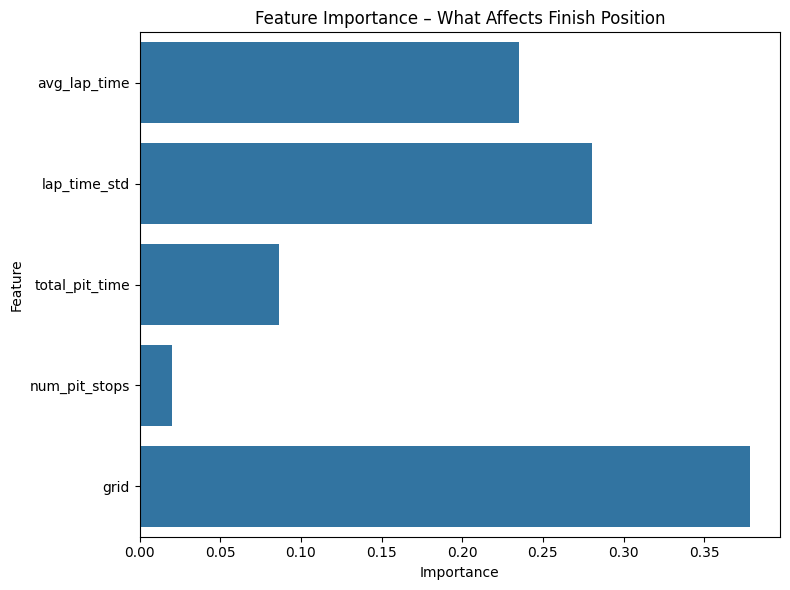

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance – What Affects Finish Position")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [94]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Initialize XGBoost model with better defaults
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, preds)
print(f"XGBoost MAE: {mae:.2f}")

XGBoost MAE: 3.38


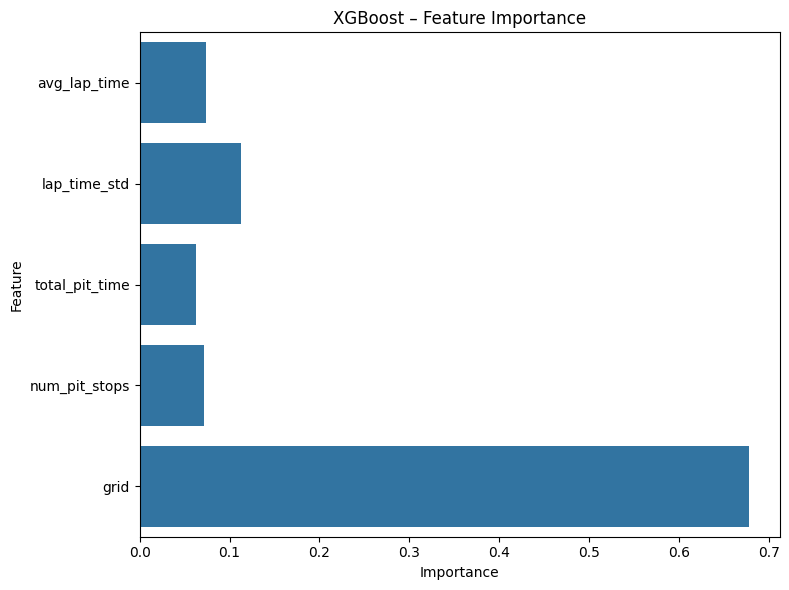

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("XGBoost – Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [97]:
# Merge races into final_data
final_data = final_data.merge(races[['raceId', 'circuitId']], on='raceId', how='left')

In [98]:
X = final_data[['avg_lap_time', 'lap_time_std', 'total_pit_time', 'num_pit_stops', 'grid', 'circuitId']]
X = pd.get_dummies(X, columns=['circuitId'])

In [99]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Step 1: Redefine features and target
y = final_data['positionOrder']  # target stays the same

# Step 2: One-hot encoded X already defined
# If not, uncomment:
# X = final_data[['avg_lap_time', 'lap_time_std', 'total_pit_time', 'num_pit_stops', 'grid', 'circuitId']]
# X = pd.get_dummies(X, columns=['circuitId'])

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train XGBoost model again
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Step 5: Predict + evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"XGBoost (with circuit info) MAE: {mae:.2f}")

XGBoost (with circuit info) MAE: 3.34


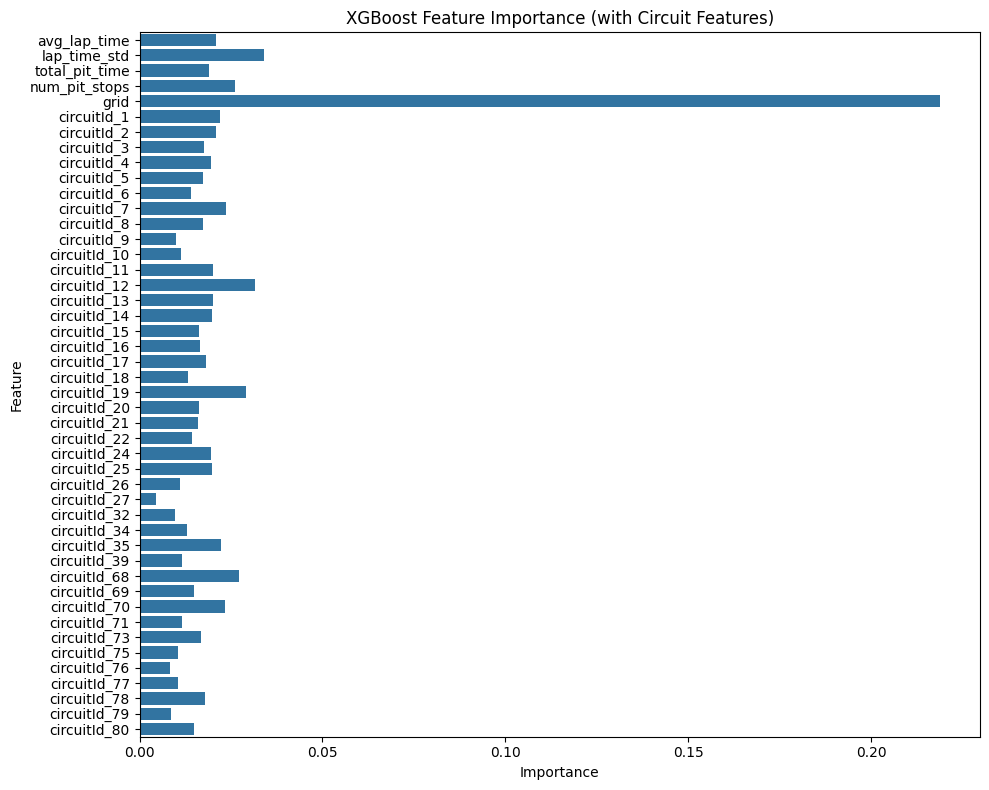

In [100]:
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 8))
sns.barplot(x=importances, y=feature_names)
plt.title("XGBoost Feature Importance (with Circuit Features)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [101]:
# XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

final_preds = (xgb_preds + rf_preds) / 2

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, final_preds)
print(f"Ensemble MAE: {mae:.2f}")


Ensemble MAE: 3.41


In [102]:
final_preds = 0.8 * xgb_preds + 0.2 * rf_preds
mae = mean_absolute_error(y_test, final_preds)
print(f"Weighted Ensemble MAE: {mae:.2f}")


Weighted Ensemble MAE: 3.37


In [103]:
final_preds = 0.9 * xgb_preds + 0.1 * rf_preds
mae = mean_absolute_error(y_test, final_preds)
print(f"Weighted Ensemble MAE: {mae:.2f}")


Weighted Ensemble MAE: 3.35


In [104]:
# Define tiers
def position_tier(pos):
    if pos <= 3:
        return 0
    elif pos <= 10:
        return 1
    else:
        return 2

final_data['position_tier'] = final_data['positionOrder'].apply(position_tier)

In [105]:
from sklearn.model_selection import train_test_split
y = final_data['position_tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [106]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [107]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6971480307831598

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.64      0.67       321
           1       0.62      0.57      0.59       775
           2       0.75      0.80      0.77      1113

    accuracy                           0.70      2209
   macro avg       0.69      0.67      0.68      2209
weighted avg       0.69      0.70      0.69      2209



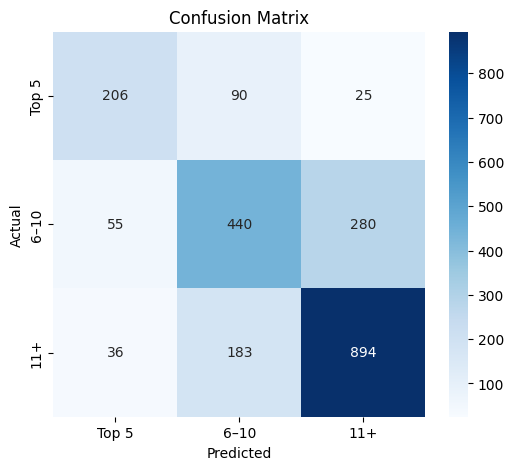

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Top 5', '6–10', '11+'], yticklabels=['Top 5', '6–10', '11+'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [109]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)


Class Weights: {np.int64(0): np.float64(2.245614035087719), np.int64(1): np.float64(0.9722589167767504), np.int64(2): np.float64(0.6552414867571779)}


In [110]:
# Assign weight to each training row based on its class
sw = y_train.map(class_weights)

In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Pass the sample weights here 👇
model.fit(X_train, y_train, sample_weight=sw)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [112]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6731552738795835

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.74      0.65       321
           1       0.58      0.57      0.58       775
           2       0.79      0.72      0.75      1113

    accuracy                           0.67      2209
   macro avg       0.65      0.68      0.66      2209
weighted avg       0.68      0.67      0.68      2209



In [113]:
# Step 1: Start with relevant numeric features
X = final_data[['avg_lap_time', 'lap_time_std', 'total_pit_time', 'num_pit_stops', 'grid']].copy()

# Step 2: Add new features with safe .loc usage
X.loc[:, 'race_distance'] = final_data['avg_lap_time'] * final_data['total_laps']
X.loc[:, 'driverId'] = final_data['driverId']
X.loc[:, 'statusId'] = final_data['statusId']
X.loc[:, 'circuitId'] = final_data['circuitId']  # also useful for classification

In [114]:
X = pd.get_dummies(X, columns=['driverId', 'statusId', 'circuitId'], drop_first=True)

In [115]:
from sklearn.model_selection import train_test_split

y = final_data['position_tier']  # 0, 1, 2
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [116]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# Sample weights for training
sample_weights = y_train.map(class_weights)


In [117]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7618832050701675

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.80      0.70       326
           1       0.67      0.66      0.66       761
           2       0.89      0.82      0.85      1122

    accuracy                           0.76      2209
   macro avg       0.73      0.76      0.74      2209
weighted avg       0.77      0.76      0.77      2209



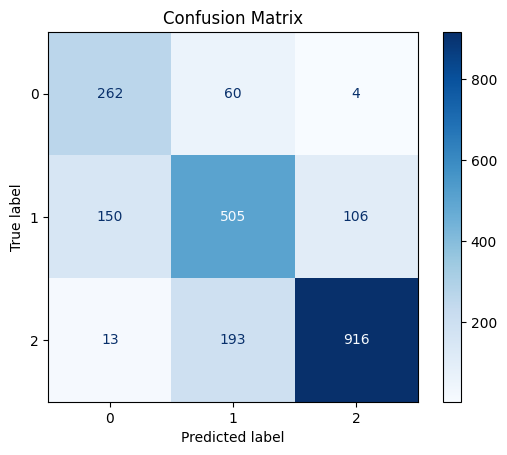

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


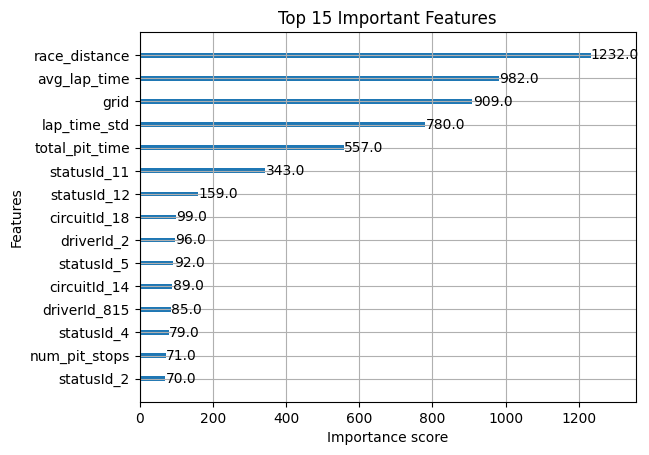

In [119]:
import xgboost as xgb
xgb.plot_importance(model, max_num_features=15)
plt.title("Top 15 Important Features")
plt.show()


In [120]:
import joblib
joblib.dump(model, 'xgb_model.pkl')

['xgb_model.pkl']

In [121]:
X.head(1).to_csv("sample_input_format.csv", index=False)


In [122]:
final_data.to_csv('../data/final_data.csv', index=False)